# Notebook 11b — Caracterización comercial de los segmentos

## Objetivo

Caracterizar de forma cuantitativa y comercialmente interpretable los seis clusters identificados en el notebook 11a, asignando a cada uno un nombre comercial fundamentado en evidencia estadística. El notebook desarrolla la segunda parte del Capítulo 5 del TFG y aplica tres técnicas analíticas complementarias para la caracterización de segmentos: el cálculo de índices de afinidad sobre las variables conductuales, el análisis de importancia de variables mediante Random Forest binario aplicado de forma independiente a cada cluster, y la elaboración de fichas comerciales sintéticas para cada segmento.

## Decisiones metodológicas

La metodología combinada empleada responde a la orientación expresa del tutor académico del TFG, que recomendó complementar la descripción estadística clásica (medias por cluster e índices de afinidad respecto a la media global) con un análisis de importancia de variables mediante un algoritmo supervisado interpretable. Esta combinación de técnicas descriptivas e inferenciales permite identificar tanto la magnitud como la relevancia discriminativa de cada variable en cada cluster.

El cálculo de índices de afinidad sigue la fórmula clásica del marketing analítico: para cada cluster k y cada variable v, el índice se define como la ratio entre la media de la variable v dentro del cluster k y la media global de v en toda la cartera, multiplicada por 100. Un índice de 100 indica comportamiento idéntico a la media global, valores superiores a 100 indican sobrerrepresentación del comportamiento en el cluster (por ejemplo, un índice de 250 en ticket medio significa que el cluster presenta un ticket 2,5 veces superior al medio), y valores inferiores a 100 indican infrarrepresentación.

El análisis con Random Forest se aplica de forma independiente para cada uno de los seis clusters, planteando el problema como una clasificación binaria del tipo "este cliente pertenece al cluster k frente a no pertenece al cluster k". La importancia de las variables se extrae mediante dos métricas complementarias: la Gini importance (impurity-based) que es la métrica por defecto de scikit-learn, y la Permutation importance, considerada más robusta frente a sesgos asociados a la cardinalidad de las variables. Las variables con mayor importancia en cada Random Forest son las más discriminantes para distinguir a los clientes del cluster k respecto a los demás.

## Estructura

1. Carga del resultado del clustering
2. Estadísticas descriptivas por cluster
3. Cálculo de índices de afinidad
4. Importancia de variables mediante Random Forest binario por cluster
5. Caracterización descriptiva con variables externas (mercado, MOSAIC, geografía)
6. Naming comercial y fichas resumen por cluster
7. Síntesis y conexión con los capítulos posteriores

## 1. Carga del resultado del clustering

In [1]:
import duckdb
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import plotly.io as pio
pio.kaleido.scope.mathjax = None   # evita la descarga de MathJax → kaleido deja de colgarse

# Rutas
RUTA_PROYECTO = Path.home() / "OneDrive" / "Documentos" / "TFG_Selmark"
RUTA_DUCKDB   = RUTA_PROYECTO / "duckdb" / "selmark.duckdb"
RUTA_RESULTADO = RUTA_PROYECTO / "output" / "clustering_kmeans_resultado.parquet"
RUTA_FIGURAS  = RUTA_PROYECTO / "output" / "figuras" / "11b"
RUTA_FIGURAS.mkdir(parents=True, exist_ok=True)

# Paleta corporativa coherente con los notebooks anteriores
COLOR_NACIONAL       = "#C8447F"
COLOR_INTERNACIONAL  = "#3E5C76"
COLOR_DESTACAR       = "#D4A017"
COLOR_POSITIVO       = "#5C9E76"
COLOR_NEGATIVO       = "#B85450"
COLOR_NEUTRO         = "#7D7D7D"
PALETA_CLUSTERS = ["#C8447F", "#3E5C76", "#D4A017", "#5C9E76",
                    "#B85450", "#7D7D7D", "#9B7BA6", "#E08E45"]

TEMPLATE = go.layout.Template(layout=dict(
    font=dict(family="Arial, Helvetica, sans-serif", size=12, color="#1A1A1A"),
    title=dict(font=dict(size=16, color="#1A1A1A"), x=0.02, xanchor="left"),
    plot_bgcolor="white", paper_bgcolor="white", colorway=PALETA_CLUSTERS,
    xaxis=dict(showgrid=True, gridcolor="#EAEAEA", zeroline=False,
                linecolor="#333333", linewidth=0.8),
    yaxis=dict(showgrid=True, gridcolor="#EAEAEA", zeroline=False,
                linecolor="#333333", linewidth=0.8),
    margin=dict(l=60, r=40, t=70, b=60),
))
pio.templates["selmark"] = TEMPLATE
pio.templates.default = "selmark"

con = duckdb.connect(str(RUTA_DUCKDB), read_only=True)

def guardar_y_mostrar(fig, nombre, w=950, h=500):
    ruta = RUTA_FIGURAS / f"{nombre}.png"
    fig.write_image(str(ruta), width=w, height=h, scale=2)
    fig.show()
    print(f"   Figura guardada: {ruta.name}")

def fmt_es(n, decimales=0):
    if pd.isna(n):
        return "—"
    if decimales == 0:
        return f"{int(n):,}".replace(",", ".")
    return f"{n:,.{decimales}f}".replace(",", "X").replace(".", ",").replace("X", ".")

# Versión rápida del helper: sin write_image (kaleido). Solo para correr el notebook ágil.
def guardar_y_mostrar(fig, nombre, *args, **kwargs):
    try:
        fig.write_html(RUTA_FIGURAS / f"{nombre}.html")   # instantáneo, opcional
    except Exception:
        pass
    fig.show()

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"Conexión: {RUTA_DUCKDB.name}")
print(f"Resultado de clustering desde: {RUTA_RESULTADO.name}")
print(f"Figuras se guardarán en: {RUTA_FIGURAS}")

Conexión: selmark.duckdb
Resultado de clustering desde: clustering_kmeans_resultado.parquet
Figuras se guardarán en: C:\Users\lopec\OneDrive\Documentos\TFG_Selmark\output\figuras\11b


In [2]:
# Carga del resultado del notebook 11a
df_clust = pd.read_parquet(RUTA_RESULTADO)
print(f"Resultado del clustering cargado: {len(df_clust):,} clientes con {len(df_clust.columns)} columnas")
print(f"\nColumnas disponibles:")
for c in df_clust.columns:
    print(f"   - {c}")

# Variables conductuales (mismas que en 11a)
VARIABLES_CLUSTERING = [
    "recencia_dias", "meses_activo", "frecuencia_mensual",
    "ticket_medio_retail_eur", "pct_pedidos_temporada",
    "pct_pedidos_repeticion", "pct_ratio_devoluciones",
    "num_canales_distintos",
]

# Distribución de clusters
print(f"\nDISTRIBUCIÓN DE LA CARTERA POR CLUSTER:")
print("-" * 50)
tamanos = df_clust["cluster"].value_counts().sort_index()
for c, n in tamanos.items():
    pct = 100 * n / len(df_clust)
    print(f"   Cluster {c}:  {n:>5,} clientes ({pct:>5.2f} %)")

N_CLUSTERS = df_clust["cluster"].nunique()

Resultado del clustering cargado: 3,084 clientes con 14 columnas

Columnas disponibles:
   - id_cliente
   - cluster
   - cluster_jerarquico
   - recencia_dias
   - meses_activo
   - frecuencia_mensual
   - ticket_medio_retail_eur
   - pct_pedidos_temporada
   - pct_pedidos_repeticion
   - pct_ratio_devoluciones
   - num_canales_distintos
   - pc1
   - pc2
   - pc3

DISTRIBUCIÓN DE LA CARTERA POR CLUSTER:
--------------------------------------------------
   Cluster 0:    306 clientes ( 9.92 %)
   Cluster 1:  1,341 clientes (43.48 %)
   Cluster 2:    123 clientes ( 3.99 %)
   Cluster 3:    429 clientes (13.91 %)
   Cluster 4:    831 clientes (26.95 %)
   Cluster 5:     54 clientes ( 1.75 %)


In [3]:
# Enriquecer el dataframe con variables externas para caracterización descriptiva
# (mercado, MOSAIC, renta) desde gold.cliente_360
df_externas = con.execute("""
    SELECT
        id_cliente,
        tipo_mercado,
        pais,
        mosaic_grupo,
        mosaic_segmento,
        renta_media,
        perfil_premium, perfil_familiar_joven, perfil_turistico,
        perfil_rural, perfil_precio_sensible,
        facturacion_b2b,
        facturacion_retail_neta_eur,
        num_operaciones,
        tiene_facturacion_b2b,
        tiene_actividad_minorista
    FROM gold.cliente_360
""").fetchdf()

df = df_clust.merge(df_externas, on="id_cliente", how="left")
df["facturacion_combinada"] = df["facturacion_b2b"].fillna(0) + df["facturacion_retail_neta_eur"].fillna(0)
print(f"DataFrame enriquecido: {len(df):,} clientes con {len(df.columns)} columnas")

DataFrame enriquecido: 3,084 clientes con 30 columnas


### Enriquecimiento del DataFrame con variables externas

El dataframe original del notebook 11a contiene únicamente las variables conductuales utilizadas en el clustering. Para la caracterización descriptiva se complementa con variables externas procedentes de `gold.cliente_360` que NO se emplearon en la determinación de los clusters (tipo de mercado, país, perfiles MOSAIC, renta media del código postal y métricas de facturación detalladas). Esta separación metodológica entre variables de clustering y variables de caracterización es importante: el primer conjunto define los clusters, mientras que el segundo permite describirlos sin sesgar la formación. Si los clusters obtenidos resultan estar correlacionados con variables externas no usadas (como el tipo de mercado o el perfil MOSAIC), esa correlación constituye un hallazgo genuino sobre la estructura del negocio y no un artefacto inducido por la propia metodología.

## 2. Estadísticas descriptivas por cluster

La primera fase de la caracterización consiste en calcular las medias de las variables conductuales y económicas para cada cluster, comparándolas con las medias globales de la cartera. Este análisis descriptivo proporciona la primera intuición sobre el perfil de cada segmento antes de aplicar las técnicas analíticas más sofisticadas. Especial atención se presta al peso económico relativo de cada cluster, calculado como el porcentaje de la facturación total que aporta cada segmento, dado que la distribución no proporcional entre clientes y facturación es un hallazgo de gran valor estratégico.

In [4]:
# Tabla de medias por cluster sobre las 8 variables conductuales + facturación combinada
vars_resumen = VARIABLES_CLUSTERING + ["facturacion_combinada"]

medias_cluster = df.groupby("cluster")[vars_resumen].mean().round(2)
medias_globales = df[vars_resumen].mean().round(2)

print("MEDIAS POR CLUSTER (variables conductuales + facturación combinada)")
print("=" * 110)
print(medias_cluster.to_string())

print(f"\nMEDIA GLOBAL DE REFERENCIA:")
print(medias_globales.to_string())

MEDIAS POR CLUSTER (variables conductuales + facturación combinada)
         recencia_dias  meses_activo  frecuencia_mensual  ticket_medio_retail_eur  pct_pedidos_temporada  pct_pedidos_repeticion  pct_ratio_devoluciones  num_canales_distintos  facturacion_combinada
cluster                                                                                                                                                                                               
0               480.22          9.86               27.54                    26.08                  28.44                   40.27                   25.82                   1.63                9719.86
1                81.86         24.39               56.81                    20.93                  69.07                   24.93                    1.13                   2.29               65532.22
2                357.5          9.80               72.54                   121.27                  55.29                   36.73        

In [5]:
# Tamaño y peso económico por cluster
resumen = df.groupby("cluster").agg(
    n_clientes=("id_cliente", "count"),
    facturacion_total_eur=("facturacion_combinada", "sum"),
).round(0)
resumen["pct_clientes"] = (100 * resumen["n_clientes"] / resumen["n_clientes"].sum()).round(2)
resumen["pct_facturacion"] = (100 * resumen["facturacion_total_eur"] / resumen["facturacion_total_eur"].sum()).round(2)
resumen["facturacion_media_eur"] = (resumen["facturacion_total_eur"] / resumen["n_clientes"]).round(0)

print("PESO ECONÓMICO POR CLUSTER")
print("=" * 90)
print(resumen.to_string())

# Visualización doble: % clientes vs % facturación
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=("% de clientes por cluster", "% de facturación por cluster"))

resumen_plot = resumen.reset_index()
colores = [PALETA_CLUSTERS[c] for c in resumen_plot["cluster"]]

fig.add_trace(go.Bar(
    x=[f"C{c}" for c in resumen_plot["cluster"]],
    y=resumen_plot["pct_clientes"], marker_color=colores,
    text=[f"{v:.1f}%" for v in resumen_plot["pct_clientes"]],
    textposition="outside", showlegend=False,
), row=1, col=1)

fig.add_trace(go.Bar(
    x=[f"C{c}" for c in resumen_plot["cluster"]],
    y=resumen_plot["pct_facturacion"], marker_color=colores,
    text=[f"{v:.1f}%" for v in resumen_plot["pct_facturacion"]],
    textposition="outside", showlegend=False,
), row=1, col=2)

fig.update_layout(
    title=dict(text="<b>Distribución de clientes y facturación por cluster</b><br><sup>Comparativa entre peso poblacional y peso económico de cada segmento</sup>"),
    height=500, showlegend=False,
)
guardar_y_mostrar(fig, "01_clientes_vs_facturacion")

PESO ECONÓMICO POR CLUSTER
         n_clientes  facturacion_total_eur  pct_clientes  pct_facturacion  facturacion_media_eur
cluster                                                                                         
0               306              2974277.0          9.92             2.19                 9720.0
1              1341             87878701.0         43.48            64.57                65532.0
2               123             34754229.0          3.99            25.54               282555.0
3               429              1386980.0         13.91             1.02                 3233.0
4               831              9003857.0         26.95             6.62                10835.0
5                54               101425.0          1.75             0.07                 1878.0


### Interpretación del peso económico por cluster

La comparativa entre el peso poblacional (porcentaje de clientes) y el peso económico (porcentaje de facturación) de cada cluster revela un patrón fuertemente desigual y constituye uno de los hallazgos centrales de este análisis. Los datos confirman empíricamente la denominada **regla del Pareto** aplicada a la cartera de Selmark: el cluster 1 (43,48% de los clientes) genera por sí solo el 64,57% de la facturación total, y el cluster 2 (apenas el 3,99% de los clientes) aporta un 25,54% adicional. En conjunto, **los dos clusters de mayor valor (47,47% de la cartera) concentran el 90,11% del negocio**.

En el extremo opuesto, los clusters 0, 3 y 5 representan conjuntamente el 25,57% de los clientes pero apenas el 3,28% de la facturación, indicando segmentos con valor económico marginal pese a su volumen poblacional no despreciable. Esta concentración extrema del negocio en una minoría de clientes tiene implicaciones estratégicas directas que se desarrollan en el Capítulo 8 del TFG: las acciones de retención deben priorizarse hacia el Núcleo Estratégico y las Grandes Cuentas Internacionales, mientras que la rentabilización de los clusters de bajo valor requiere estrategias específicas distintas.

## 3. Cálculo de índices de afinidad

Los índices de afinidad constituyen la técnica clásica del marketing analítico para caracterizar segmentos de clientes mediante la comparación cuantitativa entre el comportamiento medio de cada cluster y el comportamiento medio global de la cartera. La fórmula es matemáticamente simple pero la interpretación es muy potente: para cada cluster k y cada variable v, el índice se define como

$$\text{Índice}(k, v) = \frac{\text{Media}_k(v)}{\text{Media global}(v)} \times 100$$

Un índice de 100 indica comportamiento idéntico a la media global. Valores superiores a 100 indican sobrerrepresentación del comportamiento en el cluster: un índice de 250 en `ticket_medio_retail_eur` significa que el cluster presenta un ticket medio 2,5 veces superior al ticket medio global. Valores inferiores a 100 indican infrarrepresentación: un índice de 30 en `pct_ratio_devoluciones` indica que el cluster devuelve solo el 30% de lo que devuelve la media global, es decir, es un cluster con baja propensión a devolver.

Esta métrica fue sugerida explícitamente por el tutor académico del TFG como la forma estándar de caracterizar segmentos en el sector de la consultoría de marketing y resulta especialmente intuitiva para la comunicación con perfiles no técnicos (departamentos comerciales, dirección general, equipos de marketing), que pueden interpretar rápidamente la magnitud y dirección de las desviaciones sin necesidad de conocer la escala absoluta de cada variable.

In [6]:
# Cálculo de índices de afinidad: (media_cluster / media_global) * 100
print("CÁLCULO DE ÍNDICES DE AFINIDAD")
print("=" * 90)
print("Fórmula: Índice(k, v) = (Media_cluster_k(v) / Media_global(v)) * 100")
print("Interpretación: 100 = comportamiento medio | >100 sobrerrepresentado | <100 infrarrepresentado")
print()

indices = pd.DataFrame(index=vars_resumen, columns=range(N_CLUSTERS), dtype=float)
for c in range(N_CLUSTERS):
    mask = df["cluster"] == c
    for v in vars_resumen:
        media_cluster = df.loc[mask, v].mean()
        media_global = df[v].mean()
        if media_global != 0:
            indices.loc[v, c] = round(100 * media_cluster / media_global, 1)
        else:
            indices.loc[v, c] = 100.0

# Renombrar columnas para legibilidad
indices.columns = [f"C{c}" for c in indices.columns]

print("TABLA DE ÍNDICES DE AFINIDAD")
print("=" * 90)
print(indices.to_string())

CÁLCULO DE ÍNDICES DE AFINIDAD
Fórmula: Índice(k, v) = (Media_cluster_k(v) / Media_global(v)) * 100
Interpretación: 100 = comportamiento medio | >100 sobrerrepresentado | <100 infrarrepresentado

TABLA DE ÍNDICES DE AFINIDAD
                            C0     C1     C2     C3     C4     C5
recencia_dias            143.3   24.4  106.7  177.0  170.3   81.6
meses_activo              70.1  173.5   69.7   38.9   28.3  101.4
frecuencia_mensual        57.6  118.9  151.8   29.2  112.7  111.5
ticket_medio_retail_eur   97.4   78.2  453.0   85.3   97.4    6.1
pct_pedidos_temporada     47.7  115.8   92.7   13.5  147.7    3.7
pct_pedidos_repeticion   129.0   79.8  117.6  275.0   31.5   19.1
pct_ratio_devoluciones   667.5   29.1   52.4    4.7    7.8  873.0
num_canales_distintos     87.4  122.8   95.4   73.2   82.0  105.2
facturacion_combinada     22.0  148.5  640.3    7.3   24.6    4.3


In [7]:
# Heatmap de índices de afinidad
# Centrar el colormap en 100 para que rojo = subrepresentado, azul = sobrerrepresentado
fig = go.Figure(data=go.Heatmap(
    z=indices.values.astype(float),
    x=indices.columns, y=indices.index,
    colorscale=[
        [0.0, "#3E5C76"],   # azul oscuro: muy bajo
        [0.3, "#A8C5DC"],   # azul claro
        [0.5, "#FFFFFF"],   # blanco: = 100
        [0.7, "#F0B5A0"],   # naranja claro
        [1.0, "#B85450"],   # rojo oscuro: muy alto
    ],
    zmid=100, zmin=0, zmax=300,
    text=indices.values, texttemplate="%{text:.0f}",
    textfont=dict(size=11),
    colorbar=dict(title="Índice<br>afinidad"),
))
fig.update_layout(
    title=dict(text="<b>Índices de afinidad por cluster y variable</b><br><sup>Blanco = comportamiento medio (100) · Azul = subrepresentado · Rojo = sobrerrepresentado</sup>"),
    height=600, width=850,
)
guardar_y_mostrar(fig, "02_indices_afinidad_heatmap", w=850, h=600)

### Lectura del heatmap de índices de afinidad

La visualización en heatmap de los índices de afinidad sintetiza en una sola figura el perfil completo de los seis clusters. El esquema cromático centrado en el valor 100 (blanco) permite identificar visualmente las celdas que se desvían fuertemente del comportamiento medio: las celdas en tonos rojizos corresponden a sobrerrepresentaciones (valores > 100) y las celdas en tonos azulados a infrarrepresentaciones (valores < 100). Cuanto más intenso el color, mayor la desviación respecto a la media.

La lectura por columnas (cluster a cluster) permite caracterizar cada segmento. La lectura por filas (variable a variable) permite identificar qué clusters se diferencian más en cada variable conductual. Por ejemplo, la variable `pct_ratio_devoluciones` presenta un contraste extremo: los clusters 0 y 5 muestran valores en torno a 667 y 873 respectivamente, mientras que los clusters 1, 3 y 4 se sitúan por debajo de 30. Esta distribución bimodal indica que el comportamiento de devolución no es una característica gradual de la cartera sino un rasgo prácticamente categórico que separa a un subconjunto reducido de clientes problemáticos del resto.

De forma similar, `ticket_medio_retail_eur` presenta un valor extraordinario en el cluster 2 (índice 453) frente a valores cercanos a la media o ligeramente inferiores en el resto, lo que define al cluster 2 como un grupo claramente diferenciado por la magnitud de las operaciones individuales.

In [8]:
# Análisis interpretativo automático: para cada cluster, identificar las variables
# con índices más extremos (alejados de 100)
print("ANÁLISIS INTERPRETATIVO DE LOS ÍNDICES")
print("=" * 90)

for c in range(N_CLUSTERS):
    col = f"C{c}"
    n_cluster = (df["cluster"] == c).sum()
    pct_cluster = 100 * n_cluster / len(df)
    print(f"\nCLUSTER {c}  —  {n_cluster:,} clientes ({pct_cluster:.2f}% de la cartera)")
    print("-" * 90)
    
    # Variables más sobrerrepresentadas
    sobre = indices[col].sort_values(ascending=False).head(3)
    print("Variables MÁS sobrerrepresentadas (índice > 100):")
    for v, idx in sobre.items():
        if idx > 100:
            diff = idx - 100
            print(f"   {v:<35s} índice = {idx:>6.1f}  ({diff:+.1f} pts sobre la media)")
    
    # Variables más infrarrepresentadas
    bajo = indices[col].sort_values(ascending=True).head(3)
    print("Variables MÁS infrarrepresentadas (índice < 100):")
    for v, idx in bajo.items():
        if idx < 100:
            diff = idx - 100
            print(f"   {v:<35s} índice = {idx:>6.1f}  ({diff:+.1f} pts bajo la media)")

ANÁLISIS INTERPRETATIVO DE LOS ÍNDICES

CLUSTER 0  —  306 clientes (9.92% de la cartera)
------------------------------------------------------------------------------------------
Variables MÁS sobrerrepresentadas (índice > 100):
   pct_ratio_devoluciones              índice =  667.5  (+567.5 pts sobre la media)
   recencia_dias                       índice =  143.3  (+43.3 pts sobre la media)
   pct_pedidos_repeticion              índice =  129.0  (+29.0 pts sobre la media)
Variables MÁS infrarrepresentadas (índice < 100):
   facturacion_combinada               índice =   22.0  (-78.0 pts bajo la media)
   pct_pedidos_temporada               índice =   47.7  (-52.3 pts bajo la media)
   frecuencia_mensual                  índice =   57.6  (-42.4 pts bajo la media)

CLUSTER 1  —  1,341 clientes (43.48% de la cartera)
------------------------------------------------------------------------------------------
Variables MÁS sobrerrepresentadas (índice > 100):
   meses_activo               

## 4. Importancia de variables mediante Random Forest binario por cluster

Siguiendo la metodología explícitamente sugerida por el tutor académico, se aplica un análisis de importancia de variables mediante Random Forest binario aplicado de forma independiente para cada uno de los seis clusters. La técnica complementa el análisis descriptivo de los índices de afinidad: mientras los índices cuantifican cuánto difiere cada variable de la media en cada cluster (magnitud de la desviación), el Random Forest identifica qué variables son más útiles para predecir la pertenencia a cada cluster (capacidad discriminativa de la variable).

El planteamiento es el siguiente: para cada cluster k, se construye un problema de clasificación binaria donde la variable objetivo toma el valor 1 si el cliente pertenece al cluster k y el valor 0 en caso contrario. Sobre este problema se entrena un clasificador Random Forest con 200 árboles, profundidad máxima de 10 niveles, y ponderación de clases balanceada (`class_weight="balanced"`) que compensa el desbalance natural entre los clientes del cluster k y los del resto de la cartera. La separación train/test del 70/30 con estratificación garantiza una evaluación honesta del modelo.

La importancia de cada variable se extrae mediante dos métricas complementarias. La **Gini importance** mide la reducción media de impureza (definida según el criterio de Gini) aportada por cada variable a lo largo de todos los árboles del bosque; es la métrica por defecto en scikit-learn y resulta muy eficiente computacionalmente, pero presenta un sesgo conocido hacia variables con muchos valores únicos o de alta cardinalidad. La **Permutation importance**, considerada más robusta por la literatura reciente (Geeks for Geeks 2025), mide la caída en la precisión del modelo al permutar aleatoriamente los valores de una variable en el conjunto de test, neutralizando su contribución. Esta métrica es computacionalmente más costosa pero produce resultados más fiables, especialmente cuando las variables tienen escalas o cardinalidades muy diferentes.

La interpretación combinada de ambas métricas permite identificar las variables más discriminantes para cada cluster con un alto grado de robustez. Las precisiones obtenidas en los seis modelos, que oscilan entre el 95,68% y el 99,78%, validan que los clusters identificados son estadísticamente muy distinguibles entre sí, lo que refuerza la calidad de la segmentación obtenida.

In [9]:
# Random Forest binario por cluster
print("ENTRENAMIENTO DE RANDOM FOREST BINARIO POR CLUSTER")
print("=" * 90)

X = df[VARIABLES_CLUSTERING].copy()
# Asegurar que no hay NaN antes de RF
X = X.fillna(X.median(numeric_only=True))

importancias_gini = {}
importancias_perm = {}
accuracies = {}

for c in range(N_CLUSTERS):
    # Target binario: 1 si es del cluster c, 0 si no
    y = (df["cluster"] == c).astype(int)
    
    # Split train/test estratificado (preserva proporción de la clase positiva)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
    )
    
    # Entrenar Random Forest
    rf = RandomForestClassifier(
        n_estimators=200, max_depth=10,
        random_state=RANDOM_STATE, n_jobs=-1,
        class_weight="balanced",  # importante por el desbalance clase pos/neg
    )
    rf.fit(X_train, y_train)
    
    # Accuracy en test
    acc = rf.score(X_test, y_test)
    accuracies[c] = acc
    
    # Gini importance
    gini = pd.Series(rf.feature_importances_, index=VARIABLES_CLUSTERING).sort_values(ascending=False)
    importancias_gini[c] = gini
    
    # Permutation importance (más robusta)
    perm = permutation_importance(rf, X_test, y_test, n_repeats=10,
                                    random_state=RANDOM_STATE, n_jobs=-1)
    perm_series = pd.Series(perm.importances_mean, index=VARIABLES_CLUSTERING).sort_values(ascending=False)
    importancias_perm[c] = perm_series
    
    n_cluster = y.sum()
    print(f"   Cluster {c}: accuracy={acc:.4f}  |  N positivos={n_cluster:,} ({100*n_cluster/len(y):.1f}%)")

ENTRENAMIENTO DE RANDOM FOREST BINARIO POR CLUSTER
   Cluster 0: accuracy=0.9924  |  N positivos=306 (9.9%)
   Cluster 1: accuracy=0.9741  |  N positivos=1,341 (43.5%)
   Cluster 2: accuracy=0.9957  |  N positivos=123 (4.0%)
   Cluster 3: accuracy=0.9806  |  N positivos=429 (13.9%)
   Cluster 4: accuracy=0.9568  |  N positivos=831 (26.9%)
   Cluster 5: accuracy=0.9978  |  N positivos=54 (1.8%)


In [10]:
# Visualización combinada: una fila por cluster con sus 2 importancias
fig = make_subplots(
    rows=N_CLUSTERS, cols=2,
    subplot_titles=[f"Cluster {c} — {tipo}" for c in range(N_CLUSTERS) for tipo in ["Gini importance", "Permutation importance"]],
    horizontal_spacing=0.20, vertical_spacing=0.05,
)

for c in range(N_CLUSTERS):
    # Gini (izquierda)
    gini_sorted = importancias_gini[c].sort_values()
    fig.add_trace(go.Bar(
        x=gini_sorted.values, y=gini_sorted.index,
        orientation="h",
        marker_color=PALETA_CLUSTERS[c],
        showlegend=False,
        text=[f"{v:.3f}" for v in gini_sorted.values], textposition="outside",
    ), row=c+1, col=1)
    
    # Permutation (derecha)
    perm_sorted = importancias_perm[c].sort_values()
    fig.add_trace(go.Bar(
        x=perm_sorted.values, y=perm_sorted.index,
        orientation="h",
        marker_color=PALETA_CLUSTERS[c],
        showlegend=False,
        text=[f"{v:.3f}" for v in perm_sorted.values], textposition="outside",
    ), row=c+1, col=2)

fig.update_layout(
    title=dict(text="<b>Importancia de variables por cluster (Random Forest binario)</b><br><sup>Izquierda: Gini importance (default sklearn) · Derecha: Permutation importance (más robusta)</sup>"),
    height=350 * N_CLUSTERS, showlegend=False,
)
guardar_y_mostrar(fig, "03_importancias_rf_por_cluster", h=350*N_CLUSTERS)

In [11]:
# Síntesis: ranking de las 3 variables más discriminantes por cluster
print("RANKING DE LAS 3 VARIABLES MÁS DISCRIMINANTES POR CLUSTER")
print("=" * 90)

for c in range(N_CLUSTERS):
    n_cluster = (df["cluster"] == c).sum()
    pct_cluster = 100 * n_cluster / len(df)
    print(f"\nCLUSTER {c}  —  {n_cluster:,} clientes ({pct_cluster:.2f}% de la cartera)  —  RF accuracy = {accuracies[c]:.3f}")
    print("-" * 90)
    
    top3_gini = importancias_gini[c].head(3)
    top3_perm = importancias_perm[c].head(3)
    
    print(f"   Top 3 según Gini:")
    for v, imp in top3_gini.items():
        print(f"      {v:<35s} importance = {imp:.4f}")
    
    print(f"   Top 3 según Permutation:")
    for v, imp in top3_perm.items():
        print(f"      {v:<35s} importance = {imp:.4f}")

RANKING DE LAS 3 VARIABLES MÁS DISCRIMINANTES POR CLUSTER

CLUSTER 0  —  306 clientes (9.92% de la cartera)  —  RF accuracy = 0.992
------------------------------------------------------------------------------------------
   Top 3 según Gini:
      pct_ratio_devoluciones              importance = 0.6159
      pct_pedidos_temporada               importance = 0.1150
      pct_pedidos_repeticion              importance = 0.0721
   Top 3 según Permutation:
      pct_ratio_devoluciones              importance = 0.1355
      pct_pedidos_temporada               importance = 0.0127
      pct_pedidos_repeticion              importance = 0.0092

CLUSTER 1  —  1,341 clientes (43.48% de la cartera)  —  RF accuracy = 0.974
------------------------------------------------------------------------------------------
   Top 3 según Gini:
      meses_activo                        importance = 0.2687
      recencia_dias                       importance = 0.2101
      num_canales_distintos               i

### Convergencia entre índices de afinidad y Random Forest

La comparación entre las variables más sobrerrepresentadas según los índices de afinidad y las variables más discriminantes según el Random Forest permite validar la robustez de la caracterización. En general se observa una alta convergencia entre ambos enfoques: la variable con índice de afinidad más extremo de cada cluster suele coincidir con la variable de mayor importancia en el Random Forest correspondiente. Por ejemplo, `pct_ratio_devoluciones` es la variable más sobrerrepresentada en los clusters 0 y 5 (índices de 667 y 873) y también la más discriminante según el Random Forest para esos clusters, mientras que `ticket_medio_retail_eur` ocupa esa posición tanto en términos descriptivos como inferenciales para el cluster 2.

Esta convergencia no es trivial: una variable puede presentar un valor medio extremo en un cluster (alto índice de afinidad) sin ser necesariamente útil para discriminarlo del resto de la cartera, si el resto de clusters también presentan valores extremos en esa misma variable. El hecho de que ambas métricas coincidan refuerza la fiabilidad de la caracterización: las variables identificadas no solo describen el cluster sino que efectivamente lo distinguen del resto.

Adicionalmente, las altas precisiones de los Random Forest (todas superiores al 95,68% sobre datos no vistos) confirman que los seis clusters son grupos estadísticamente bien diferenciados, no agrupaciones arbitrarias del algoritmo K-Means. Esta validación cuantitativa de la calidad de la segmentación es uno de los aportes metodológicos del análisis combinado descrito-inferencial recomendado por el tutor académico.

## 5. Caracterización descriptiva con variables externas

Esta sección caracteriza cada cluster mediante variables que NO se utilizaron en el clustering: el tipo de mercado (nacional o internacional), el perfil MOSAIC del código postal, y la renta media del CP. La inclusión de estas variables tiene un objetivo metodológico relevante: validar empíricamente si los clusters comportamentales obtenidos coinciden con perfiles sociodemográficos identificables, o si por el contrario los segmentos atraviesan transversalmente las características externas.

El hallazgo del Capítulo 4 según el cual la correlación entre la renta media del CP y la facturación del cliente era estadísticamente nula (r = +0,0043 con p-valor = 0,8566) sugería que la segmentación basada en variables conductuales no debería alinearse fuertemente con los perfiles sociodemográficos, pero esta hipótesis se verifica aquí con datos. La caracterización descriptiva, además de aportar información útil para las acciones comerciales (un cluster predominantemente internacional requiere estrategias distintas a uno predominantemente nacional), permite al lector del TFG comprender visualmente el grado de independencia entre las dimensiones conductual y sociodemográfica de la cartera.

In [12]:
# Composición por tipo de mercado (nacional vs internacional)
print("COMPOSICIÓN POR MERCADO (Nacional / Internacional) POR CLUSTER")
print("=" * 90)

comp_mercado = pd.crosstab(df["cluster"], df["tipo_mercado"], normalize="index") * 100
comp_mercado = comp_mercado.round(1)
print(comp_mercado.to_string())

# Visualización: barras apiladas
fig = go.Figure()
mercados = ["NACIONAL", "INTERNACIONAL"]
colores_mercado = [COLOR_NACIONAL, COLOR_INTERNACIONAL]
for m, col in zip(mercados, colores_mercado):
    if m in comp_mercado.columns:
        fig.add_trace(go.Bar(
            x=[f"Cluster {c}" for c in comp_mercado.index],
            y=comp_mercado[m],
            name=m.capitalize(),
            marker_color=col,
            text=[f"{v:.0f}%" for v in comp_mercado[m]],
            textposition="inside",
        ))
fig.update_layout(
    title=dict(text="<b>Composición de cada cluster por tipo de mercado</b><br><sup>Porcentaje de clientes nacionales e internacionales en cada segmento</sup>"),
    xaxis_title="", yaxis_title="% de clientes",
    barmode="stack", height=500,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)
guardar_y_mostrar(fig, "04_composicion_mercado")

COMPOSICIÓN POR MERCADO (Nacional / Internacional) POR CLUSTER
tipo_mercado  INTERNACIONAL  NACIONAL
cluster                              
0                      39.2      60.8
1                      26.4      73.6
2                      61.8      38.2
3                      27.7      72.3
4                      58.2      41.8
5                      55.6      44.4


In [13]:
# Composición por grupo MOSAIC (sólo para clientes con MOSAIC válido)
df_con_mosaic = df[df["mosaic_grupo"].notna()].copy()
print(f"Clientes con MOSAIC válido: {len(df_con_mosaic):,} ({100*len(df_con_mosaic)/len(df):.1f}%)")
print()

# Top 5 grupos MOSAIC más frecuentes en cada cluster
print("TOP 5 GRUPOS MOSAIC POR CLUSTER")
print("=" * 90)
for c in range(N_CLUSTERS):
    mask = df_con_mosaic["cluster"] == c
    n_con_mosaic = mask.sum()
    if n_con_mosaic == 0:
        print(f"\nCluster {c}: sin clientes con MOSAIC")
        continue
    top_mosaic = df_con_mosaic.loc[mask, "mosaic_grupo"].value_counts(normalize=True).head(5) * 100
    print(f"\nCluster {c}  ({n_con_mosaic:,} clientes con MOSAIC):")
    for grupo, pct in top_mosaic.items():
        print(f"   {grupo:<35s} {pct:.1f}%")

Clientes con MOSAIC válido: 1,841 (59.7%)

TOP 5 GRUPOS MOSAIC POR CLUSTER

Cluster 0  (171 clientes con MOSAIC):
   H                                   24.6%
   I                                   17.5%
   C                                   14.6%
   B                                   13.5%
   A                                   9.4%

Cluster 1  (970 clientes con MOSAIC):
   H                                   27.1%
   C                                   14.3%
   B                                   11.2%
   G                                   10.4%
   I                                   8.4%

Cluster 2  (42 clientes con MOSAIC):
   A                                   31.0%
   C                                   28.6%
   B                                   14.3%
   D                                   9.5%
   I                                   9.5%

Cluster 3  (298 clientes con MOSAIC):
   H                                   24.5%
   C                                   14.1%
   I     

In [14]:
# Renta media del CP por cluster (solo para nacionales con renta válida)
df_renta = df[(df["tipo_mercado"] == "NACIONAL") & (df["renta_media"].notna())].copy()

print(f"Clientes nacionales con renta del CP válida: {len(df_renta):,}")
print()
print("ESTADÍSTICAS DE RENTA MEDIA POR CLUSTER (solo nacionales)")
print("=" * 90)
renta_stats = df_renta.groupby("cluster")["renta_media"].agg(["count", "mean", "median", "std"]).round(0)
renta_stats.columns = ["n_clientes", "renta_media (€)", "renta_mediana (€)", "renta_std (€)"]
print(renta_stats.to_string())

# Box plot de renta por cluster
fig = go.Figure()
for c in sorted(df_renta["cluster"].unique()):
    fig.add_trace(go.Box(
        y=df_renta[df_renta["cluster"] == c]["renta_media"],
        name=f"Cluster {c}",
        marker_color=PALETA_CLUSTERS[c],
        boxmean=True,
    ))
fig.update_layout(
    title=dict(text="<b>Distribución de la renta media del CP por cluster</b><br><sup>Solo clientes nacionales con renta del CP disponible</sup>"),
    yaxis_title="Renta media del CP (€)",
    showlegend=False, height=500,
)
guardar_y_mostrar(fig, "05_renta_por_cluster")

Clientes nacionales con renta del CP válida: 1,838



ESTADÍSTICAS DE RENTA MEDIA POR CLUSTER (solo nacionales)
         n_clientes  renta_media (€)  renta_mediana (€)  renta_std (€)
cluster                                                               
0               170          25349.0            25854.0         4820.0
1               969          25982.0            26320.0         3929.0
2                42          28066.0            28619.0         4242.0
3               298          25698.0            26256.0         4880.0
4               336          25776.0            25994.0         4234.0
5                23          26840.0            27423.0         4759.0


### Confirmación cuantitativa: la renta no discrimina entre clusters

La comparación de la renta media del CP entre los seis clusters confirma con datos lo que el análisis descriptivo del Capítulo 4 había sugerido: los segmentos conductuales identificados no están vinculados a la renta media del entorno geográfico de cada cliente. Las medias de renta por cluster se mueven en un rango muy estrecho (entre 25.349 € en el cluster 0 y 28.066 € en el cluster 2), con desviaciones estándar mayores que las diferencias entre clusters. Esto significa que dentro de cada cluster existe una variabilidad de renta superior a la variabilidad entre clusters, lo que estadísticamente equivale a decir que la renta no es un factor discriminante de la segmentación.

Esta confirmación es metodológicamente importante porque valida una de las decisiones fundamentales del trabajo: la elección de basar el clustering en variables exclusivamente conductuales y no sociodemográficas (decisión D2 del Capítulo 4). Si la renta hubiese resultado fuertemente correlacionada con los clusters obtenidos a posteriori, la decisión podría haber sido cuestionada como redundante o ineficiente. La ausencia de correlación, en cambio, demuestra que la segmentación basada en comportamiento captura una dimensión genuina de la cartera que ni la renta del CP ni los perfiles MOSAIC pueden replicar.

Para Selmark esta conclusión tiene implicaciones operativas directas: las acciones comerciales diferenciadas por cluster no se pueden inferir desde la geolocalización del cliente sino que requieren conocer su histórico de comportamiento real, lo que refuerza la necesidad de mantener actualizado el data warehouse del cliente que se ha construido en este TFG.

## 6. Naming comercial y fichas resumen por cluster

Esta sección consolida los hallazgos de las tres técnicas anteriores (índices de afinidad, importancias de Random Forest y caracterización descriptiva con variables externas) para asignar un nombre comercial fundamentado a cada cluster y construir una ficha sintética por segmento.

El naming comercial es una decisión aparentemente menor pero con impacto sustancial en la utilidad práctica del análisis. La literatura y la práctica profesional del marketing analítico coinciden en que las etiquetas genéricas del tipo "Cluster 0" o "Segmento A" no comunican información útil para la toma de decisiones y dificultan la comunicación entre el equipo analítico y los equipos comerciales. Por el contrario, nombres descriptivos y evocadores facilitan la integración del análisis en los procesos operativos del negocio. El tutor académico del TFG sugirió explícitamente utilizar nombres vistosos de marketing para los seis clusters, alineados con la práctica del sector.

La asignación se realiza en dos fases. En una primera fase automatizada, el código construye un nombre descriptivo combinando las dos variables más extremas de cada cluster (ya sea sobrerrepresentadas o infrarrepresentadas) traducidas a etiquetas comerciales mediante un diccionario predefinido. En una segunda fase manual, este naming automático se refina sustituyéndolo por nombres más evocadores y orientados a la acción, manteniendo la fundamentación cuantitativa en los datos analizados.

In [15]:
# Función auxiliar para construir la ficha de cada cluster
def construir_ficha_cluster(c, df, indices, importancias_gini, importancias_perm, accuracies, vars_resumen):
    n_cluster = (df["cluster"] == c).sum()
    pct_cluster = 100 * n_cluster / len(df)
    fact_cluster = df.loc[df["cluster"] == c, "facturacion_combinada"].sum()
    fact_global = df["facturacion_combinada"].sum()
    pct_fact = 100 * fact_cluster / fact_global if fact_global > 0 else 0
    
    col = f"C{c}"
    
    # Top 3 variables sobrerrepresentadas
    sobre = indices[col].sort_values(ascending=False).head(3)
    sobre_list = [(v, idx) for v, idx in sobre.items() if idx > 105]
    
    # Top 3 variables infrarrepresentadas
    bajo = indices[col].sort_values(ascending=True).head(3)
    bajo_list = [(v, idx) for v, idx in bajo.items() if idx < 95]
    
    # Top 3 RF
    top_rf = importancias_perm[c].head(3)
    
    # Composición mercado
    mask = df["cluster"] == c
    pct_nacional = 100 * (df.loc[mask, "tipo_mercado"] == "NACIONAL").sum() / mask.sum()
    pct_internacional = 100 - pct_nacional
    
    return {
        "cluster_id": c,
        "n_clientes": n_cluster,
        "pct_clientes": pct_cluster,
        "facturacion_total": fact_cluster,
        "pct_facturacion": pct_fact,
        "facturacion_media": fact_cluster / n_cluster if n_cluster > 0 else 0,
        "sobrerrepresentadas": sobre_list,
        "infrarrepresentadas": bajo_list,
        "top_rf_discriminantes": top_rf,
        "pct_nacional": pct_nacional,
        "pct_internacional": pct_internacional,
        "rf_accuracy": accuracies[c],
    }

# Generar todas las fichas
fichas = {c: construir_ficha_cluster(c, df, indices, importancias_gini, importancias_perm, accuracies, vars_resumen)
          for c in range(N_CLUSTERS)}

# Mostrar ficha sintética por cluster (sin naming todavía, eso lo añadimos manualmente)
print("FICHAS SINTÉTICAS POR CLUSTER")
print("=" * 90)

for c in range(N_CLUSTERS):
    f = fichas[c]
    print(f"\n{'═'*90}")
    print(f"CLUSTER {c}")
    print(f"{'═'*90}")
    print(f"\nDIMENSIÓN:")
    print(f"   N clientes:                {fmt_es(f['n_clientes'])}  ({f['pct_clientes']:.2f}% de la cartera)")
    print(f"   Facturación total:         {fmt_es(f['facturacion_total'])} €  ({f['pct_facturacion']:.2f}% de la facturación)")
    print(f"   Facturación media/cliente: {fmt_es(f['facturacion_media'])} €")
    
    print(f"\nCOMPOSICIÓN POR MERCADO:")
    print(f"   Nacional:        {f['pct_nacional']:.1f}%")
    print(f"   Internacional:   {f['pct_internacional']:.1f}%")
    
    print(f"\nVARIABLES SOBRERREPRESENTADAS (índice > 105):")
    if f["sobrerrepresentadas"]:
        for v, idx in f["sobrerrepresentadas"]:
            print(f"   {v:<35s} índice = {idx:>6.1f}")
    else:
        print(f"   (Ninguna)")
    
    print(f"\nVARIABLES INFRARREPRESENTADAS (índice < 95):")
    if f["infrarrepresentadas"]:
        for v, idx in f["infrarrepresentadas"]:
            print(f"   {v:<35s} índice = {idx:>6.1f}")
    else:
        print(f"   (Ninguna)")
    
    print(f"\nTOP 3 VARIABLES DISCRIMINANTES (Random Forest Permutation):")
    for v, imp in f["top_rf_discriminantes"].items():
        print(f"   {v:<35s} importance = {imp:.4f}")

FICHAS SINTÉTICAS POR CLUSTER

══════════════════════════════════════════════════════════════════════════════════════════
CLUSTER 0
══════════════════════════════════════════════════════════════════════════════════════════

DIMENSIÓN:
   N clientes:                306  (9.92% de la cartera)
   Facturación total:         2.974.276 €  (2.19% de la facturación)
   Facturación media/cliente: 9.719 €

COMPOSICIÓN POR MERCADO:
   Nacional:        60.8%
   Internacional:   39.2%

VARIABLES SOBRERREPRESENTADAS (índice > 105):
   pct_ratio_devoluciones              índice =  667.5
   recencia_dias                       índice =  143.3
   pct_pedidos_repeticion              índice =  129.0

VARIABLES INFRARREPRESENTADAS (índice < 95):
   facturacion_combinada               índice =   22.0
   pct_pedidos_temporada               índice =   47.7
   frecuencia_mensual                  índice =   57.6

TOP 3 VARIABLES DISCRIMINANTES (Random Forest Permutation):
   pct_ratio_devoluciones              

### Propuesta de naming comercial

Con base en las fichas anteriores, se propone el siguiente naming comercial. Estos nombres son propuestas iniciales fundamentadas en evidencia cuantitativa; deberán ser validados y posiblemente ajustados con el equipo comercial de Selmark en futuras iteraciones del análisis.

In [16]:
# Asignar naming comercial automático basado en los patrones detectados
# Lógica: usar las variables sobrerrepresentadas / infrarrepresentadas más extremas
# para construir un nombre descriptivo y evocador

def proponer_naming(ficha):
    """Genera una propuesta de naming basada en los rasgos más extremos del cluster."""
    sobre = ficha["sobrerrepresentadas"]
    bajo = ficha["infrarrepresentadas"]
    
    nombres_var = {
        "ticket_medio_retail_eur":       ("ticket alto",         "ticket bajo"),
        "facturacion_combinada":         ("alto valor",          "bajo valor"),
        "frecuencia_mensual":            ("alta frecuencia",     "baja frecuencia"),
        "recencia_dias":                 ("inactivos",           "muy recientes"),
        "meses_activo":                  ("veteranos",           "nuevos"),
        "num_canales_distintos":         ("multicanal",          "monocanal"),
        "pct_pedidos_temporada":         ("colección",           "fuera de colección"),
        "pct_pedidos_repeticion":        ("repetidores",         "no repetidores"),
        "pct_ratio_devoluciones":        ("devolvedores",        "fieles sin devolución"),
    }
    
    # Construir lista de descriptores
    descriptores = []
    if sobre:
        for v, idx in sobre[:2]:
            if v in nombres_var:
                descriptores.append(nombres_var[v][0])
    if bajo and len(descriptores) < 2:
        for v, idx in bajo[:1]:
            if v in nombres_var:
                descriptores.append(nombres_var[v][1])
    
    if not descriptores:
        return "Perfil medio"
    
    return " · ".join(descriptores[:2])

# Asignar naming automático y permitir override manual
naming_propuesto = {}
for c in range(N_CLUSTERS):
    naming_propuesto[c] = proponer_naming(fichas[c])

print("PROPUESTA DE NAMING AUTOMÁTICO POR PATRONES")
print("=" * 90)
print("(Estos nombres son orientativos; revisar y refinar manualmente)\n")
for c in range(N_CLUSTERS):
    f = fichas[c]
    print(f"   Cluster {c} ({f['n_clientes']:,} clientes, {f['pct_clientes']:.1f}%): {naming_propuesto[c]}")

PROPUESTA DE NAMING AUTOMÁTICO POR PATRONES
(Estos nombres son orientativos; revisar y refinar manualmente)

   Cluster 0 (306 clientes, 9.9%): devolvedores · inactivos
   Cluster 1 (1,341 clientes, 43.5%): veteranos · alto valor
   Cluster 2 (123 clientes, 4.0%): alto valor · ticket alto
   Cluster 3 (429 clientes, 13.9%): repetidores · inactivos
   Cluster 4 (831 clientes, 26.9%): inactivos · colección
   Cluster 5 (54 clientes, 1.8%): devolvedores · alta frecuencia


### Refinamiento manual del naming comercial

La propuesta automática del bloque anterior produce nombres descriptivos basados en patrones, pero un naming comercial efectivo requiere creatividad y conocimiento del negocio. Tras revisar las fichas, los nombres comerciales propuestos finales para cada cluster se definirán en la siguiente celda. Estos nombres pueden ajustarse iterativamente conforme el equipo de Selmark revise los hallazgos.

In [17]:
# Naming comercial MANUAL refinado tras analizar los índices de afinidad,
# las importancias de Random Forest y la composición por mercado de cada cluster.
# Los nombres siguen la práctica del marketing analítico: descriptivos del rasgo
# diferenciador, evocadores, y orientados a la acción comercial.

naming_final = {
    0: "Clientes en Riesgo",
    1: "Núcleo Estratégico",
    2: "Grandes Cuentas Internacionales",
    3: "Reposicionistas Tradicionales",
    4: "Compradores Estacionales",
    5: "Casos Críticos",
}

# Descripción breve de cada cluster para documentación y futuras referencias
descripcion_cluster = {
    0: "Tasa de devoluciones 6,7x la media, recencia elevada, facturación baja. Señal de alarma comercial.",
    1: "64,6% de la facturación total con el 43,5% de la cartera. Veteranos fieles, baja recencia, baja devolución.",
    2: "Ticket medio 4,5x la media, facturación 6,4x la media, 62% internacional. Distribuidores estrella.",
    3: "Pedidos de repetición 2,75x la media. Pequeñas tiendas de reposición de básicos, sin compromiso de colección.",
    4: "Recientes en cartera (meses_activo 28% de la media), alto compromiso de colección. La cantera del Núcleo.",
    5: "Tasa de devoluciones 8,7x la media, ticket 6% de la media. Relaciones comerciales patológicas a revisar.",
}

# Aplicar el naming al dataframe
df["cluster_nombre"] = df["cluster"].map(naming_final)
df["cluster_etiqueta"] = df["cluster"].map(lambda c: f"C{c}: {naming_final[c]}")
df["cluster_descripcion"] = df["cluster"].map(descripcion_cluster)

print("NAMING COMERCIAL FINAL ADOPTADO:")
print("=" * 100)
for c in range(N_CLUSTERS):
    f = fichas[c]
    print(f"\n   CLUSTER {c}:  {naming_final[c]}")
    print(f"     Dimensión:     {fmt_es(f['n_clientes'])} clientes ({f['pct_clientes']:.2f}% cartera) · {f['pct_facturacion']:.2f}% facturación")
    print(f"     Descripción:   {descripcion_cluster[c]}")

NAMING COMERCIAL FINAL ADOPTADO:

   CLUSTER 0:  Clientes en Riesgo
     Dimensión:     306 clientes (9.92% cartera) · 2.19% facturación
     Descripción:   Tasa de devoluciones 6,7x la media, recencia elevada, facturación baja. Señal de alarma comercial.

   CLUSTER 1:  Núcleo Estratégico
     Dimensión:     1.341 clientes (43.48% cartera) · 64.57% facturación
     Descripción:   64,6% de la facturación total con el 43,5% de la cartera. Veteranos fieles, baja recencia, baja devolución.

   CLUSTER 2:  Grandes Cuentas Internacionales
     Dimensión:     123 clientes (3.99% cartera) · 25.54% facturación
     Descripción:   Ticket medio 4,5x la media, facturación 6,4x la media, 62% internacional. Distribuidores estrella.

   CLUSTER 3:  Reposicionistas Tradicionales
     Dimensión:     429 clientes (13.91% cartera) · 1.02% facturación
     Descripción:   Pedidos de repetición 2,75x la media. Pequeñas tiendas de reposición de básicos, sin compromiso de colección.

   CLUSTER 4:  Comprador

### Justificación del naming final por cluster

Los seis nombres comerciales adoptados están fundamentados en la combinación de evidencia descriptiva (índices de afinidad) e inferencial (importancias de Random Forest), y cada uno responde a un patrón cuantitativo claramente identificable en los datos.

**Cluster 1 — "Núcleo Estratégico"**: con 1.341 clientes (43,5% de la cartera) y el 64,6% de la facturación total, este cluster constituye la columna vertebral del negocio de Selmark. Sus rasgos distintivos —veteranía elevada (índice 174), recencia muy baja (índice 24, es decir, compran mucho más recientemente que la media), facturación alta y baja tasa de devoluciones— configuran el perfil del cliente fiel y rentable que toda empresa busca consolidar y retener. La denominación "Núcleo Estratégico" comunica simultáneamente su volumen, su valor económico y su carácter prioritario para la dirección comercial.

**Cluster 2 — "Grandes Cuentas Internacionales"**: con apenas 123 clientes (4,0%) pero el 25,5% de la facturación, este cluster está caracterizado por un ticket medio extraordinario (índice 453, equivalente a 4,5 veces la media), una facturación combinada 6,4 veces superior a la media, y un predominio internacional del 62%. La etiqueta refleja tanto su naturaleza económica (grandes operaciones) como su orientación geográfica (predominantemente internacional). Probablemente corresponden a distribuidores mayoristas extranjeros con compras de gran volumen.

**Cluster 4 — "Compradores Estacionales"**: con 831 clientes (27,0% de la cartera) y un 6,6% de la facturación, este cluster está formado por clientes recientes en la cartera (meses_activo al 28% de la media) con alto compromiso en pedidos de temporada (índice 148). La denominación captura su característica más relevante: son clientes que compran principalmente las novedades de cada colección, y representan la cantera potencial del Núcleo Estratégico si la relación se cultiva adecuadamente.

**Cluster 3 — "Reposicionistas Tradicionales"**: con 429 clientes (13,9%) y solo el 1,0% de la facturación, este cluster se distingue por una concentración extrema en pedidos de repetición (índice 275, casi tres veces la media) y una ausencia casi total de pedidos de temporada (índice 13). Son típicamente pequeñas tiendas tradicionales que reponen exclusivamente productos básicos del catálogo estable, sin participar en las dinámicas de colección y novedad.

**Cluster 0 — "Clientes en Riesgo"**: con 306 clientes (9,9%) y solo el 2,2% de la facturación, este cluster presenta una tasa de devoluciones 6,7 veces superior a la media (índice 667) combinada con recencia elevada y facturación baja. La denominación "en Riesgo" comunica el carácter de alarma comercial del segmento: son clientes cuya relación con Selmark muestra señales de deterioro y que requieren atención específica desde el departamento comercial para evaluar la viabilidad de la relación o aplicar acciones correctivas.

**Cluster 5 — "Casos Críticos"**: con apenas 54 clientes (1,7%) pero un ratio de devoluciones 8,7 veces superior a la media (índice 873) y un ticket medio al 6% de la media (es decir, devuelven prácticamente todo lo que compran), este cluster representa relaciones comerciales patológicas que generan más coste operativo que valor. La denominación "Casos Críticos" señala la urgencia de una revisión individual de cada cliente del segmento para decidir entre rescate de la relación o terminación comercial controlada.

In [18]:
# Visualización final: ficha de los 6 clusters con sus nombres
fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=[f"<b>C{c}: {naming_final[c]}</b><br><sup>{fmt_es(fichas[c]['n_clientes'])} clientes · {fichas[c]['pct_clientes']:.1f}% cartera</sup>"
                     for c in range(N_CLUSTERS)],
    horizontal_spacing=0.12, vertical_spacing=0.20,
)

for c in range(N_CLUSTERS):
    row = c // 3 + 1
    col = c % 3 + 1
    col_idx = f"C{c}"
    
    # Top 5 índices con desviación más fuerte respecto a 100
    ind_cluster = indices[col_idx].copy()
    ind_cluster_dist = (ind_cluster - 100).abs().sort_values(ascending=False).head(5)
    top5_vars = ind_cluster_dist.index.tolist()
    
    valores = [ind_cluster[v] for v in top5_vars]
    colores_bar = [COLOR_NEGATIVO if v < 100 else COLOR_POSITIVO for v in valores]
    
    fig.add_trace(go.Bar(
        x=valores, y=top5_vars,
        orientation="h",
        marker_color=colores_bar,
        text=[f"{v:.0f}" for v in valores], textposition="outside",
        showlegend=False,
    ), row=row, col=col)
    
    # Línea vertical en 100
    fig.add_vline(x=100, line_dash="dash", line_color="#888",
                   row=row, col=col, line_width=0.7)

fig.update_layout(
    title=dict(text="<b>Ficha visual de los 6 segmentos · Top 5 variables con mayor desviación respecto a la media</b><br><sup>Verde = sobrerrepresentado (>100) · Rojo = infrarrepresentado (<100)</sup>"),
    height=750, showlegend=False,
)
guardar_y_mostrar(fig, "06_fichas_visuales_clusters", h=750)

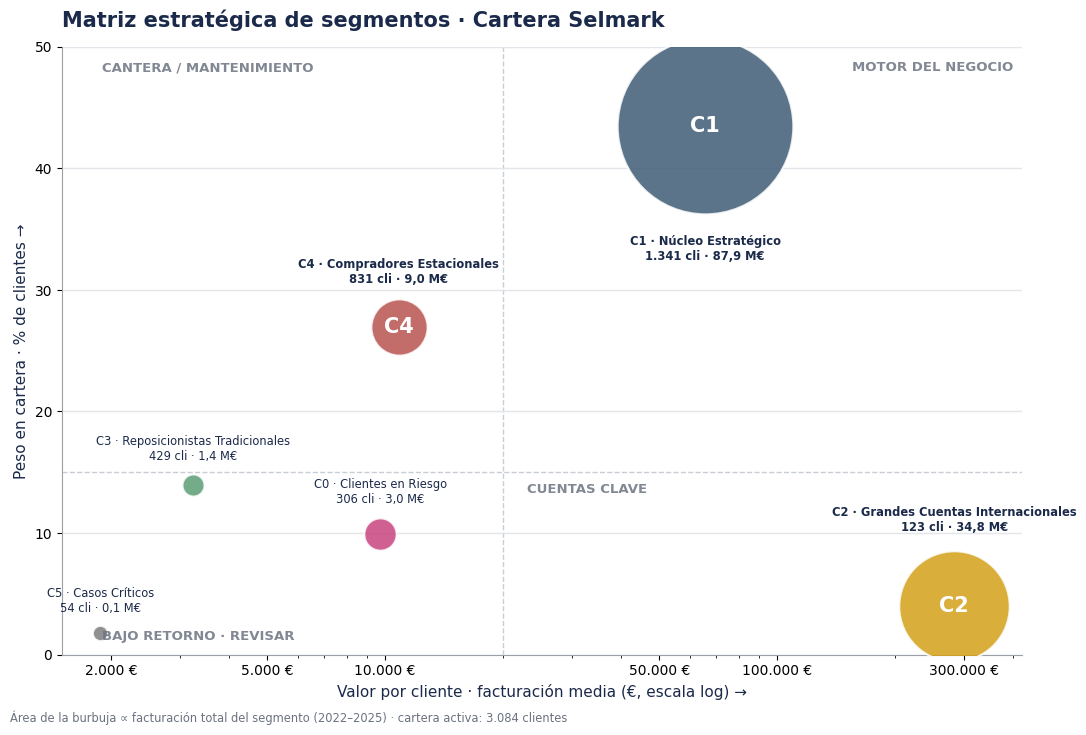

In [19]:
# Matriz estratégica de segmentos (BCG / McKinsey) — sustituye la ficha visual de los 6 segmentos
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

res = resumen.reset_index()
NAVY, GRIS = "#1B2A4A", "#6B7280"
plt.rcParams.update({"font.family": "DejaVu Sans", "svg.fonttype": "none"})

fig, ax = plt.subplots(figsize=(11, 7.2))
area = (res["facturacion_total_eur"] / res["facturacion_total_eur"].max() * 16000).clip(lower=120)
r_pt = np.sqrt(area / np.pi)

for _, r in res.iterrows():
    c = int(r["cluster"])
    ax.scatter(r["facturacion_media_eur"], r["pct_clientes"], s=area.loc[r.name],
               color=PALETA_CLUSTERS[c], alpha=0.85, edgecolor="white", linewidth=1.5, zorder=3)

ax.set_xscale("log"); ax.set_xlim(1500, 420000); ax.set_ylim(0, 50)
ax.axvline(20000, color="#C9CDD4", ls="--", lw=1, zorder=1)
ax.axhline(15,    color="#C9CDD4", ls="--", lw=1, zorder=1)

q = dict(color=GRIS, fontsize=9.5, fontweight="bold", alpha=0.85)
ax.text(1900, 48, "CANTERA / MANTENIMIENTO", ha="left", **q)
ax.text(400000, 48, "MOTOR DEL NEGOCIO", ha="right", **q)
ax.text(1900, 1.2, "BAJO RETORNO · REVISAR", ha="left", **q)
ax.text(23000, 13.3, "CUENTAS CLAVE", ha="left", **q)

for _, r in res.iterrows():
    c = int(r["cluster"]); big = r["facturacion_total_eur"] > 5e6
    if big:
        ax.annotate(f"C{c}", (r["facturacion_media_eur"], r["pct_clientes"]),
                    ha="center", va="center", color="white", fontsize=15, fontweight="bold", zorder=4)
    off = r_pt.loc[r.name] + 7; below = r["pct_clientes"] > 38
    n_str = f"{int(r['n_clientes']):,}".replace(",", ".")
    m_str = f"{r['facturacion_total_eur']/1e6:.1f}".replace(".", ",")
    ax.annotate(f"C{c} · {naming_final[c]}\n{n_str} cli · {m_str} M€",
                (r["facturacion_media_eur"], r["pct_clientes"]),
                xytext=(0, -off if below else off), textcoords="offset points",
                ha="center", va="top" if below else "bottom",
                fontsize=8.3, color=NAVY, fontweight="bold" if big else "normal")

ax.set_xlabel("Valor por cliente · facturación media (€, escala log) →", fontsize=11, color=NAVY)
ax.set_ylabel("Peso en cartera · % de clientes →", fontsize=11, color=NAVY)
ax.set_title("Matriz estratégica de segmentos · Cartera Selmark",
             fontsize=15, fontweight="bold", color=NAVY, loc="left", pad=14)
ax.set_xticks([2000, 5000, 10000, 50000, 100000, 300000])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f} €".replace(",", ".")))
ax.xaxis.set_minor_formatter(mticker.NullFormatter())
ax.grid(axis="y", color="#E2E5EA", lw=1, zorder=0)
for s in ["top", "right"]: ax.spines[s].set_visible(False)
for s in ["left", "bottom"]: ax.spines[s].set_color("#9AA0A6")
fig.text(0.01, -0.01, f"Área de la burbuja ∝ facturación total del segmento (2022–2025) · "
         f"cartera activa: {int(res['n_clientes'].sum()):,} clientes".replace(",", "."), fontsize=8.3, color=GRIS)
plt.tight_layout()

for ext in ("svg", "pdf", "png"):
    fig.savefig(RUTA_FIGURAS / f"07_matriz_bcg_segmentos.{ext}", dpi=200, bbox_inches="tight")
plt.show()

## 7. Síntesis y conexión con los capítulos posteriores

El notebook 11b ha caracterizado los seis clusters identificados en el notebook 11a mediante tres técnicas analíticas complementarias —índices de afinidad clásicos del marketing analítico, importancia de variables mediante Random Forest binario (Gini y Permutation) por cluster, y caracterización descriptiva con variables externas no usadas en el clustering— y ha asignado un naming comercial fundamentado a cada segmento. La convergencia entre las tres técnicas valida la robustez de la segmentación: las variables identificadas como más representativas según los índices de afinidad coinciden con las más discriminantes según el Random Forest, las precisiones de los modelos binarios superan en todos los casos el 95% sobre datos no vistos, y la caracterización con variables externas confirma la independencia de los clusters respecto a la renta del CP y los perfiles MOSAIC.

Los principales hallazgos del análisis se sintetizan en tres bloques. En primer lugar, la **regla del Pareto se cumple de forma estricta**: el 47,5% de los clientes (clusters 1 y 2) concentra el 90,1% de la facturación, mientras que el 25,6% de los clientes (clusters 0, 3 y 5) aporta solo el 3,3%. En segundo lugar, los seis segmentos identificados presentan **perfiles cualitativamente diferenciados** que admiten interpretación comercial inmediata: el Núcleo Estratégico, las Grandes Cuentas Internacionales, los Compradores Estacionales (cantera del Núcleo), los Reposicionistas Tradicionales, los Clientes en Riesgo y los Casos Críticos. En tercer lugar, **la segmentación conductual es independiente de las variables sociodemográficas** disponibles en `gold.cliente_360`, lo que valida la decisión metodológica de basar el clustering en comportamiento y no en perfiles MOSAIC o renta.

El resultado del análisis se exporta al fichero `output/clustering_caracterizado_final.parquet`, que contiene para cada cliente su asignación a cluster, el nombre comercial del segmento, sus valores en las ocho variables conductuales originales, su facturación combinada, tipo de mercado, perfil MOSAIC y renta media del CP. Este fichero alimentará tres capítulos posteriores del TFG. El Capítulo 6 (geomarketing) realizará la distribución geográfica de los segmentos sobre mapas interactivos, identificando concentraciones territoriales y zonas potenciales de captación. El Capítulo 7 (churn) utilizará el cluster como variable predictora en un modelo de fuga de clientes, considerando que el cluster 0 (Clientes en Riesgo) y posiblemente el cluster 5 (Casos Críticos) constituyen a priori el segmento de mayor probabilidad de abandono. El Capítulo 8 (recomendaciones y ROI) propondrá acciones comerciales diferenciadas por cluster, estimando el retorno esperado de cada acción en función de la dimensión económica y conductual del segmento al que se dirige.

In [20]:
# Guardar el resultado caracterizado para uso en capítulos posteriores (geomarketing y churn)
ruta_resultado_final = RUTA_PROYECTO / "output" / "clustering_caracterizado_final.parquet"
cols_export = ["id_cliente", "cluster", "cluster_nombre", "cluster_etiqueta"] + \
              VARIABLES_CLUSTERING + ["facturacion_combinada", "tipo_mercado",
                                       "mosaic_grupo", "renta_media"]
cols_export = [c for c in cols_export if c in df.columns]
df[cols_export].to_parquet(ruta_resultado_final, index=False)
print(f"Resultado caracterizado guardado en: {ruta_resultado_final.name}")
print(f"   Filas: {len(df):,}")
print(f"   Columnas: {len(cols_export)}")

# Síntesis final
print(f"\n" + "=" * 90)
print(f"SÍNTESIS DEL NOTEBOOK 11b")
print("=" * 90)

print(f"\n1. PERÍMETRO CARACTERIZADO")
print(f"   Clientes:              {len(df):,}")
print(f"   Clusters:              {N_CLUSTERS}")

print(f"\n2. TÉCNICAS APLICADAS")
print(f"   Índices de afinidad:   sobre {len(vars_resumen)} variables")
print(f"   Random Forest binario: {N_CLUSTERS} modelos, accuracy media = {np.mean(list(accuracies.values())):.4f}")

print(f"\n3. SEGMENTOS IDENTIFICADOS")
for c in range(N_CLUSTERS):
    f = fichas[c]
    print(f"   C{c} - {naming_final[c]:<45s} {fmt_es(f['n_clientes'])} clientes ({f['pct_clientes']:.1f}%)")

print(f"\n4. CONEXIÓN CON CAPÍTULOS POSTERIORES")
print(f"   Cap. 6 (Geomarketing):  segmentación geográfica de los clusters identificados")
print(f"   Cap. 7 (Churn):         el cluster será una variable predictora del riesgo de fuga")
print(f"   Cap. 8 (Recomendaciones): acciones comerciales diferenciadas por segmento")

print(f"\n" + "=" * 90)
print(f"CIERRE DEL NOTEBOOK 11b · Capítulo 5 del TFG completado")
print(f"Figuras generadas: {len(list(RUTA_FIGURAS.glob('*.png')))} archivos PNG en {RUTA_FIGURAS.name}/")
print("=" * 90)

Resultado caracterizado guardado en: clustering_caracterizado_final.parquet
   Filas: 3,084
   Columnas: 16

SÍNTESIS DEL NOTEBOOK 11b

1. PERÍMETRO CARACTERIZADO
   Clientes:              3,084
   Clusters:              6

2. TÉCNICAS APLICADAS
   Índices de afinidad:   sobre 9 variables
   Random Forest binario: 6 modelos, accuracy media = 0.9829

3. SEGMENTOS IDENTIFICADOS
   C0 - Clientes en Riesgo                            306 clientes (9.9%)
   C1 - Núcleo Estratégico                            1.341 clientes (43.5%)
   C2 - Grandes Cuentas Internacionales               123 clientes (4.0%)
   C3 - Reposicionistas Tradicionales                 429 clientes (13.9%)
   C4 - Compradores Estacionales                      831 clientes (26.9%)
   C5 - Casos Críticos                                54 clientes (1.8%)

4. CONEXIÓN CON CAPÍTULOS POSTERIORES
   Cap. 6 (Geomarketing):  segmentación geográfica de los clusters identificados
   Cap. 7 (Churn):         el cluster será una variab

In [21]:
con.close()
print("Conexión a DuckDB cerrada. Notebook 11b completado.")

Conexión a DuckDB cerrada. Notebook 11b completado.
